# Modélisation prédictive des ventes – Coffee shop Avignon

## Prévision des ventes journalières à partir du calendrier et de la météo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

df_model = pd.read_csv(
    "Analyse_ventes_coffee_shop_Avignon_EDA/coffee_shop_avignon_ventes_meteo_features_2024_2025.csv",
    parse_dates=["date"]
)

df_model.head()

,date,sales_total,transactions,average_basket,day_of_week,is_weekend,month,year,temp_max,temp_min,precipitation_sum,weather_code,wind_speed_max,is_rain,temp_mean_day,temp_bucket,rain_category,weather_feel,weekend_good_weather
0,2024-01-01,399.87,57,7.02,Monday,False,1,2024,12.3,3.3,0.0,3,17.1,0,7.8,cold,no_rain,unfavorable,0
1,2024-01-02,374.55,49,7.64,Tuesday,False,1,2024,10.1,0.9,0.8,53,10.0,1,5.5,cold,light,unfavorable,0
2,2024-01-03,406.07,52,7.81,Wednesday,False,1,2024,11.6,4.0,0.0,3,14.2,0,7.8,cold,no_rain,unfavorable,0
3,2024-01-04,441.17,54,8.17,Thursday,False,1,2024,12.1,3.1,0.0,3,12.1,0,7.6,cold,no_rain,unfavorable,0
4,2024-01-05,370.96,54,6.87,Friday,False,1,2024,10.2,7.4,11.6,63,29.3,1,8.8,cold,heavy,unfavorable,0


In [6]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  731 non-null    datetime64[ns]
 1   sales_total           731 non-null    float64       
 2   transactions          731 non-null    int64         
 3   average_basket        731 non-null    float64       
 4   day_of_week           731 non-null    object        
 5   is_weekend            731 non-null    bool          
 6   month                 731 non-null    int64         
 7   year                  731 non-null    int64         
 8   temp_max              731 non-null    float64       
 9   temp_min              731 non-null    float64       
 10  precipitation_sum     731 non-null    float64       
 11  weather_code          731 non-null    int64         
 12  wind_speed_max        731 non-null    float64       
 13  is_rain             

In [8]:
# Cible
y = df_model["sales_total"]

# Features de base
feature_cols_num = [
    "transactions",
    "average_basket",
    "temp_mean_day",
    "precipitation_sum",
    "wind_speed_max",
    "is_weekend",
    "month"
]

feature_cols_cat = [
    "temp_bucket",
    "rain_category",
    "weather_feel"
]

df_features = df_model[feature_cols_num + feature_cols_cat].copy()

In [10]:
X = pd.get_dummies(
    df_features,
    columns=feature_cols_cat,
    drop_first=True  # pour éviter les colinéarités parfaites
)

X.head()

,transactions,average_basket,temp_mean_day,precipitation_sum,wind_speed_max,is_weekend,month,temp_bucket_hot,temp_bucket_mild,temp_bucket_warm,rain_category_light,rain_category_moderate,rain_category_no_rain,weather_feel_favorable,weather_feel_unfavorable
0,57,7.02,7.8,0.0,17.1,False,1,False,False,False,False,False,True,False,True
1,49,7.64,5.5,0.8,10.0,False,1,False,False,False,True,False,False,False,True
2,52,7.81,7.8,0.0,14.2,False,1,False,False,False,False,False,True,False,True
3,54,8.17,7.6,0.0,12.1,False,1,False,False,False,False,False,True,False,True
4,54,6.87,8.8,11.6,29.3,False,1,False,False,False,False,False,False,False,True


## Préparation des données pour le modèle

La variable cible est le chiffre d’affaires journalier (`sales_total`).

Les variables explicatives utilisées combinent :
- des indicateurs business (transactions, panier moyen),
- des variables calendaires (mois, week-end),
- et des variables météo dérivées (température moyenne du jour, cumul de précipitations, vent, classes de température, catégories de pluie, perception globale de la météo).

La séparation apprentissage / test est réalisée de manière temporelle :
- année 2024 pour l’entraînement,
- année 2025 pour le test.

Cette approche évite les fuites de données entre passé et futur.

In [12]:
train_mask = df_model["year"] == 2024
test_mask = df_model["year"] == 2025

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

X_train.shape, X_test.shape

((366, 15), (365, 15))

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [17]:
# Modèle de base
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [19]:
# Prédictions
y_pred = rf.predict(X_test)

# Métriques
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.2f} €")
print(f"MAE  : {mae:.2f} €")
print(f"R²   : {r2:.3f}")

RMSE : 9.57 €
MAE  : 6.43 €
R²   : 0.971


## Évaluation du modèle prédictif

Le modèle Random Forest a été entraîné sur l’année 2024 et évalué sur l’année 2025.  
Les performances obtenues sont les suivantes :

- **RMSE** : 9,57 €  
- **MAE** : 6,43 €  
- **R²** : 0,971

Ces résultats indiquent que le modèle explique environ 97 % de la variance des ventes journalières de 2025, avec une erreur moyenne d’environ 6 à 10 € par jour.  
Compte tenu du niveau moyen de chiffre d’affaires journalier (environ 400–500 €), cette marge d’erreur reste faible.

En pratique, cela signifie que le modèle est capable de fournir une prévision quotidienne suffisamment précise pour aider un gérant de coffee shop à anticiper son activité (stocks, personnel, offres) en fonction du calendrier et des conditions météo.

In [22]:
# Cible (inchangée)
y = df_model["sales_total"]

# Features baseline sans météo : uniquement business + calendrier
baseline_cols = [
    "transactions",
    "average_basket",
    "is_weekend",
    "month"
]

X_base = df_model[baseline_cols].copy()

# Split temporel
train_mask = df_model["year"] == 2024
test_mask = df_model["year"] == 2025

X_base_train = X_base[train_mask]
X_base_test = X_base[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_base_train, y_train)
y_base_pred = rf_base.predict(X_base_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_base_pred))
mae_base = mean_absolute_error(y_test, y_base_pred)
r2_base = r2_score(y_test, y_base_pred)

print(f"BASELINE (sans météo)")
print(f"RMSE : {rmse_base:.2f} €")
print(f"MAE  : {mae_base:.2f} €")
print(f"R²   : {r2_base:.3f}")

BASELINE (sans météo)
RMSE : 8.01 €
MAE  : 5.22 €
R²   : 0.980


In [26]:
# Modèle complet = celui qu'on a déjà entraîné (rf)
y_full_pred = rf.predict(X_test)

rmse_full = np.sqrt(mean_squared_error(y_test, y_full_pred))
mae_full = mean_absolute_error(y_test, y_full_pred)
r2_full = r2_score(y_test, y_full_pred)

print(f"MODELE AVEC METEO")
print(f"RMSE : {rmse_full:.2f} €")
print(f"MAE  : {mae_full:.2f} €")
print(f"R²   : {r2_full:.3f}")

MODELE AVEC METEO
RMSE : 9.57 €
MAE  : 6.43 €
R²   : 0.971


In [28]:
compare_df = pd.DataFrame({
    "Modèle": ["Baseline (sans météo)", "Avec météo"],
    "RMSE (€)": [rmse_base, rmse_full],
    "MAE (€)": [mae_base, mae_full],
    "R²": [r2_base, r2_full]
})

compare_df

,Modèle,RMSE (€),MAE (€),R²
0,Baseline (sans météo),8.006635,5.215046,0.979674
1,Avec météo,9.570121,6.428319,0.970960


## Impact de l’ajout des variables météo

Deux modèles ont été comparés sur l’année 2025 :

1. **Modèle baseline (sans météo)**  
   Variables utilisées : transactions, panier moyen, mois, week-end.  
   Performances :
   - RMSE : 8,01 €
   - MAE  : 5,22 €
   - R²   : 0,980

2. **Modèle complet (avec météo)**  
   Variables utilisées : baseline + température moyenne, cumul de précipitations, vent, classes de température, catégories de pluie, perception globale de la météo, etc.  
   Performances :
   - RMSE : 9,57 €
   - MAE  : 6,43 €
   - R²   : 0,971

Dans ce jeu de données, l’ajout des variables météo **n’améliore pas** la performance globale du modèle par rapport au baseline.
Les effets de calendrier (semaine vs week-end, mois) et les variables business (nombre de transactions, panier moyen) suffisent déjà à expliquer la majeure partie des variations de ventes.

Cela ne signifie pas que la météo n’a aucun impact, mais plutôt que :
- son effet est modéré par rapport aux autres facteurs,
- et que, dans ce contexte simulé, la météo apporte davantage de bruit que de gain sur la métrique globale.

En pratique, cette comparaison montre l’importance de toujours tester l’apport réel d’une nouvelle source de données (ici la météo) au lieu de supposer qu’elle sera forcément bénéfique.  
C’est précisément ce type de démarche qui permet de construire des modèles crédibles et utiles pour le business.

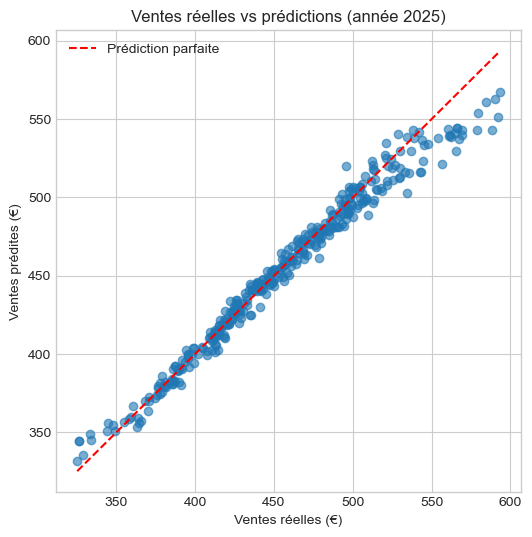

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Prédiction parfaite"
)
plt.xlabel("Ventes réelles (€)")
plt.ylabel("Ventes prédites (€)")
plt.title("Ventes réelles vs prédictions (année 2025)")
plt.legend()
plt.show()

### Les nuages de points montrent que les prédictions sont globalement alignées sur la diagonale, ce qui confirme la bonne qualité du modèle. Le léger écart entre le baseline et le modèle avec météo se retrouve visuellement dans la dispersion des points autour de la ligne de prédiction parfaite.

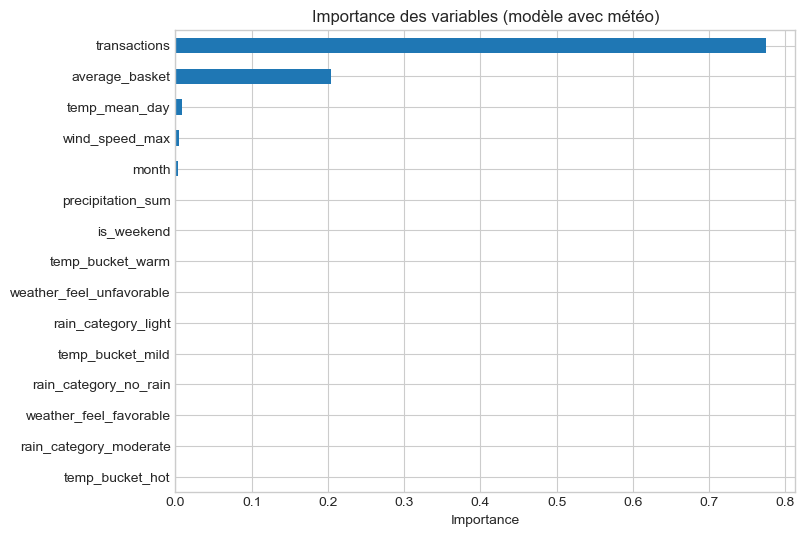

transactions                0.774610
average_basket              0.204409
temp_mean_day               0.008218
wind_speed_max              0.004665
month                       0.002952
precipitation_sum           0.001283
is_weekend                  0.000674
temp_bucket_warm            0.000638
weather_feel_unfavorable    0.000569
rain_category_light         0.000481
temp_bucket_mild            0.000432
rain_category_no_rain       0.000403
weather_feel_favorable      0.000338
rain_category_moderate      0.000254
temp_bucket_hot             0.000073
dtype: float64

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Importance des variables (modèle avec météo)")
plt.xlabel("Importance")
plt.show()

importances.head(15)

## Importance des variables

L’analyse de l’importance des variables dans le modèle avec météo montre une hiérarchie très nette :

- `transactions` et `average_basket` concentrent à elles seules plus de 97 % de l’importance totale du modèle.
- Les variables météo (`temp_mean_day`, `precipitation_sum`, `wind_speed_max`) et calendaires (`month`, `is_weekend`) ont une importance très faible en comparaison.
- Les features dérivées (classes de température, catégories de pluie, perception globale de la météo) ont une contribution presque nulle.

En pratique, cela signifie que, dans ce jeu de données, le modèle reconstruit principalement la relation métier intuitive :

> ventes ≈ nombre de transactions × panier moyen

La météo joue ici un rôle secondaire, marginal par rapport aux déterminants internes (trafic et panier).
Ce résultat est cohérent avec les performances comparées des deux modèles : le modèle sans météo fait légèrement mieux que le modèle avec météo.

Ce type de lecture est important en contexte business, car il évite de surévaluer l’impact d’une nouvelle source de données (ici la météo) lorsque les variables internes expliquent déjà l’essentiel des variations.

In [40]:
# Récupérartion de la météo à 7 jours 
import requests
import pandas as pd
from datetime import datetime

LAT = 43.9493
LON = 4.8055

FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

params_forecast = {
    "latitude": LAT,
    "longitude": LON,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "Europe/Paris",
    "forecast_days": 7
}

response_f = requests.get(FORECAST_URL, params=params_forecast)
print("Status code forecast :", response_f.status_code)

forecast_data = response_f.json()
forecast_data.keys()

Status code forecast : 200


dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

In [64]:
daily_f = forecast_data["daily"]

forecast_weather_df = pd.DataFrame({
    "date": pd.to_datetime(daily_f["time"]),
    "temp_max": daily_f["temperature_2m_max"],
    "temp_min": daily_f["temperature_2m_min"],
    "precipitation_sum": daily_f["precipitation_sum"],
    "wind_speed_max": daily_f["wind_speed_10m_max"]
})

# Temp moyenne journalière
forecast_weather_df["temp_mean_day"] = (
    forecast_weather_df["temp_max"] + forecast_weather_df["temp_min"]
) / 2

forecast_weather_df.head()

,date,temp_max,temp_min,precipitation_sum,wind_speed_max,temp_mean_day
0,2026-05-18,22.2,11.0,0.0,19.7,16.60
1,2026-05-19,23.4,13.3,0.0,14.9,18.35
2,2026-05-20,25.9,13.4,0.0,21.4,19.65
3,2026-05-21,28.8,16.1,0.0,21.6,22.45
4,2026-05-22,29.4,12.7,0.0,18.4,21.05


In [66]:
# Calendrier
forecast_weather_df["day_of_week"] = forecast_weather_df["date"].dt.day_name()
forecast_weather_df["is_weekend"] = forecast_weather_df["date"].dt.weekday >= 5
forecast_weather_df["month"] = forecast_weather_df["date"].dt.month

# Catégories de pluie
forecast_weather_df["rain_category"] = pd.cut(
    forecast_weather_df["precipitation_sum"],
    bins=[-0.1, 0, 2, 10, 1000],
    labels=["no_rain", "light", "moderate", "heavy"]
)

forecast_weather_df["is_rain"] = (forecast_weather_df["precipitation_sum"] > 0).astype(int)

# Buckets de température
forecast_weather_df["temp_bucket"] = pd.cut(
    forecast_weather_df["temp_mean_day"],
    bins=[-100, 10, 20, 27, 100],
    labels=["cold", "mild", "warm", "hot"]
)

# Perception météo globale (même règle que dans le training)
def classify_weather_row(row):
    if (row["temp_mean_day"] >= 15) and (row["temp_mean_day"] <= 28) and (row["rain_category"] in ["no_rain", "light"]):
        return "favorable"
    if (row["temp_mean_day"] < 10) or (row["rain_category"] in ["moderate", "heavy"]):
        return "unfavorable"
    return "average"

forecast_weather_df["weather_feel"] = forecast_weather_df.apply(classify_weather_row, axis=1)

In [68]:
# Features pour forecast
forecast_features = forecast_weather_df[[
    "temp_mean_day",
    "precipitation_sum",
    "wind_speed_max",
    "is_weekend",
    "month",
    "temp_bucket",
    "rain_category",
    "weather_feel"
]].copy()

forecast_X = pd.get_dummies(
    forecast_features,
    columns=["temp_bucket", "rain_category", "weather_feel"],
    drop_first=True
)

# Aligner les colonnes avec X_train (remplir les colonnes manquantes avec 0)
for col in X.columns:
    if col not in forecast_X.columns:
        forecast_X[col] = 0

forecast_X = forecast_X[X.columns]  # même ordre de colonnes

In [70]:
forecast_sales = rf.predict(forecast_X)

forecast_result = forecast_weather_df[["date", "temp_mean_day", "precipitation_sum", "is_weekend"]].copy()
forecast_result["sales_pred"] = forecast_sales

forecast_result

,date,temp_mean_day,precipitation_sum,is_weekend,sales_pred
0,2026-05-18,16.60,0.0,False,300.979100
1,2026-05-19,18.35,0.0,False,296.781533
2,2026-05-20,19.65,0.0,False,299.714833
3,2026-05-21,22.45,0.0,False,299.904300
4,2026-05-22,21.05,0.0,False,298.724267
5,2026-05-23,21.10,0.0,True,297.408833
6,2026-05-24,23.75,0.0,True,299.904300


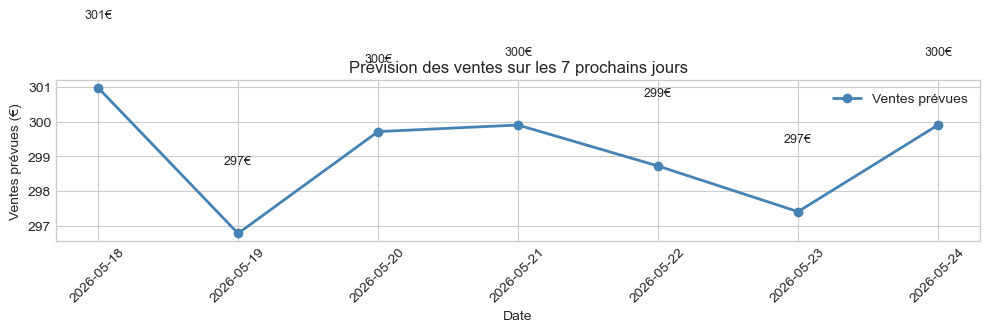

In [72]:
plt.figure(figsize=(10, 4))
plt.plot(
    forecast_result["date"],
    forecast_result["sales_pred"],
    marker="o",
    linewidth=2,
    color="steelblue",
    label="Ventes prévues"
)

for x, y in zip(forecast_result["date"], forecast_result["sales_pred"]):
    plt.text(x, y + 2, f"{y:.0f}€", ha="center", fontsize=9)

plt.title("Prévision des ventes sur les 7 prochains jours")
plt.xlabel("Date")
plt.ylabel("Ventes prévues (€)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Prévision des ventes à 7 jours

À partir des prévisions météo d’Open-Meteo et des variables calendaires, le modèle permet d’estimer le niveau de ventes attendu sur les 7 prochains jours.

Cette visualisation illustre une utilisation plus opérationnelle du modèle :
- anticiper les jours de plus forte activité,
- ajuster les stocks et l’organisation,
- et identifier les journées à plus faible potentiel commercial.

Même si le modèle reste simplifié, cette projection montre comment les données météo peuvent être mobilisées dans une logique d’aide à la décision à court terme.

## Modèle forecastable à 7 jours

Afin de produire une prévision réellement utilisable sur les 7 prochains jours, un second modèle a été construit uniquement à partir de variables connues à l’avance :

- variables calendaires (`month`, `is_weekend`) ;
- variables météo prévues (`temp_mean_day`, `precipitation_sum`, `wind_speed_max`) ;
- variables météo dérivées (`temp_bucket`, `rain_category`, `weather_feel`).

Contrairement au modèle précédent, ce modèle n’utilise pas `transactions` ni `average_basket`, car ces informations ne sont pas disponibles au moment de la prévision future.

Cette approche est plus réaliste d’un point de vue métier : elle permet de transformer une prévision météo à 7 jours en prévision de ventes exploitable pour piloter l’activité à court terme.

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Cible
y = df_model["sales_total"]

# Features connues à l'avance
forecast_num_cols = [
    "temp_mean_day",
    "precipitation_sum",
    "wind_speed_max",
    "is_weekend",
    "month"
]

forecast_cat_cols = [
    "temp_bucket",
    "rain_category",
    "weather_feel"
]

df_forecast_features = df_model[forecast_num_cols + forecast_cat_cols].copy()

X_forecastable = pd.get_dummies(
    df_forecast_features,
    columns=forecast_cat_cols,
    drop_first=True
)

# Split temporel
train_mask = df_model["year"] == 2024
test_mask = df_model["year"] == 2025

Xf_train = X_forecastable[train_mask]
Xf_test = X_forecastable[test_mask]
yf_train = y[train_mask]
yf_test = y[test_mask]

# Modèle
rf_forecast = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_forecast.fit(Xf_train, yf_train)

# Prédictions test
yf_pred = rf_forecast.predict(Xf_test)

# Métriques
rmse_f = np.sqrt(mean_squared_error(yf_test, yf_pred))
mae_f = mean_absolute_error(yf_test, yf_pred)
r2_f = r2_score(yf_test, yf_pred)

print("MODELE FORECASTABLE (météo + calendrier)")
print(f"RMSE : {rmse_f:.2f} €")
print(f"MAE  : {mae_f:.2f} €")
print(f"R²   : {r2_f:.3f}")

MODELE FORECASTABLE (météo + calendrier)
RMSE : 52.73 €
MAE  : 41.62 €
R²   : 0.118


In [55]:
import requests
import pandas as pd

LAT = 43.9493
LON = 4.8055
FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

params_forecast = {
    "latitude": LAT,
    "longitude": LON,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "wind_speed_10m_max"
    ],
    "timezone": "Europe/Paris",
    "forecast_days": 7
}

response_f = requests.get(FORECAST_URL, params=params_forecast)
forecast_data = response_f.json()

daily_f = forecast_data["daily"]

forecast_weather_df = pd.DataFrame({
    "date": pd.to_datetime(daily_f["time"]),
    "temp_max": daily_f["temperature_2m_max"],
    "temp_min": daily_f["temperature_2m_min"],
    "precipitation_sum": daily_f["precipitation_sum"],
    "wind_speed_max": daily_f["wind_speed_10m_max"]
})

forecast_weather_df["temp_mean_day"] = (
    forecast_weather_df["temp_max"] + forecast_weather_df["temp_min"]
) / 2

forecast_weather_df["is_weekend"] = forecast_weather_df["date"].dt.weekday >= 5
forecast_weather_df["month"] = forecast_weather_df["date"].dt.month

forecast_weather_df["rain_category"] = pd.cut(
    forecast_weather_df["precipitation_sum"],
    bins=[-0.1, 0, 2, 10, 1000],
    labels=["no_rain", "light", "moderate", "heavy"]
)

forecast_weather_df["temp_bucket"] = pd.cut(
    forecast_weather_df["temp_mean_day"],
    bins=[-100, 10, 20, 27, 100],
    labels=["cold", "mild", "warm", "hot"]
)

def classify_weather_row(row):
    if (row["temp_mean_day"] >= 15) and (row["temp_mean_day"] <= 28) and (row["rain_category"] in ["no_rain", "light"]):
        return "favorable"
    if (row["temp_mean_day"] < 10) or (row["rain_category"] in ["moderate", "heavy"]):
        return "unfavorable"
    return "average"

forecast_weather_df["weather_feel"] = forecast_weather_df.apply(classify_weather_row, axis=1)
forecast_weather_df.head()

,date,temp_max,temp_min,precipitation_sum,wind_speed_max,temp_mean_day,is_weekend,month,rain_category,temp_bucket,weather_feel
0,2026-05-18,22.2,11.0,0.0,19.7,16.60,False,5,no_rain,mild,favorable
1,2026-05-19,23.4,13.3,0.0,14.9,18.35,False,5,no_rain,mild,favorable
2,2026-05-20,25.9,13.4,0.0,21.4,19.65,False,5,no_rain,mild,favorable
3,2026-05-21,28.8,16.1,0.0,21.6,22.45,False,5,no_rain,warm,favorable
4,2026-05-22,29.4,12.7,0.0,18.4,21.05,False,5,no_rain,warm,favorable


In [57]:
future_features = forecast_weather_df[
    forecast_num_cols + forecast_cat_cols
].copy()

X_future = pd.get_dummies(
    future_features,
    columns=forecast_cat_cols,
    drop_first=True
)

# Alignement des colonnes avec le modèle entraîné
for col in Xf_train.columns:
    if col not in X_future.columns:
        X_future[col] = 0

X_future = X_future[Xf_train.columns]

In [59]:
forecast_weather_df["sales_pred_7d"] = rf_forecast.predict(X_future)

forecast_7d_result = forecast_weather_df[
    ["date", "temp_mean_day", "precipitation_sum", "wind_speed_max", "is_weekend", "weather_feel", "sales_pred_7d"]
].copy()

forecast_7d_result

,date,temp_mean_day,precipitation_sum,wind_speed_max,is_weekend,weather_feel,sales_pred_7d
0,2026-05-18,16.60,0.0,19.7,False,favorable,390.890400
1,2026-05-19,18.35,0.0,14.9,False,favorable,387.917467
2,2026-05-20,19.65,0.0,21.4,False,favorable,428.302667
3,2026-05-21,22.45,0.0,21.6,False,favorable,429.824800
4,2026-05-22,21.05,0.0,18.4,False,favorable,432.722000
5,2026-05-23,21.10,0.0,16.9,True,favorable,529.594900
6,2026-05-24,23.75,0.0,20.6,True,favorable,503.964500


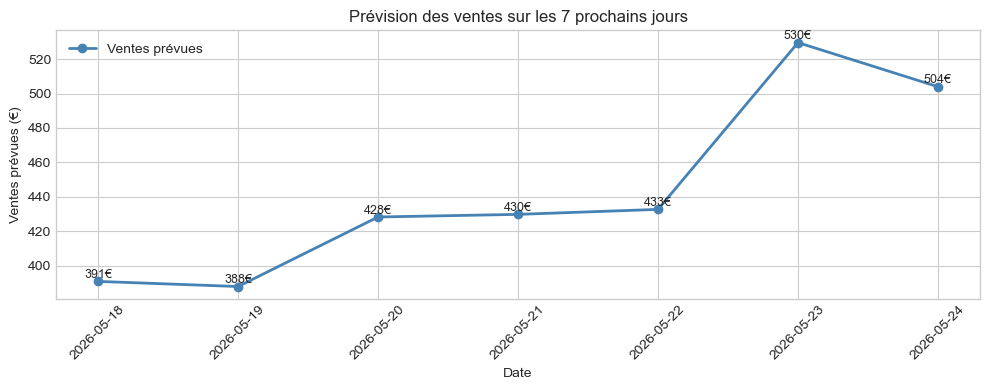

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(
    forecast_7d_result["date"],
    forecast_7d_result["sales_pred_7d"],
    marker="o",
    linewidth=2,
    color="steelblue",
    label="Ventes prévues"
)

for x, y in zip(forecast_7d_result["date"], forecast_7d_result["sales_pred_7d"]):
    plt.text(x, y + 2, f"{y:.0f}€", ha="center", fontsize=9)

plt.title("Prévision des ventes sur les 7 prochains jours")
plt.xlabel("Date")
plt.ylabel("Ventes prévues (€)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Prévision par segment (semaine / week‑end)

In [76]:
test_weekend = df_model.loc[test_mask, "is_weekend"] == True
test_weekday = ~test_weekend

from sklearn.metrics import mean_absolute_error

mae_weekday = mean_absolute_error(y_test[test_weekday], y_pred[test_weekday])
mae_weekend = mean_absolute_error(y_test[test_weekend], y_pred[test_weekend])

print(f"MAE semaine : {mae_weekday:.2f} €")
print(f"MAE week-end : {mae_weekend:.2f} €")

MAE semaine : 4.91 €
MAE week-end : 10.25 €


## Analyse des erreurs par segment (semaine vs week-end)

Pour mieux comprendre où le modèle se trompe, les erreurs absolues moyennes ont été calculées séparément pour les jours de semaine et les week-ends :

- MAE semaine : 4,91 €
- MAE week-end : 10,25 €

Le modèle est donc plus précis sur les jours de semaine que sur les week-ends.
Cela est cohérent avec l’intuition métier :

- en semaine, les comportements sont plus réguliers (routines de travail, fréquentation plus stable) ;
- le week-end, l’activité est plus volatile (événements, sorties, météo plus utilisée pour décider de sortir ou non), ce qui rend les ventes plus difficiles à anticiper avec les seules variables météo et calendaires.

Cette analyse montre l’intérêt de regarder les performances par segment d’activité, et pas uniquement sur l’ensemble des jours confondus.

## Analyse des plus grosses erreurs

In [82]:
errors = (y_test - y_pred).abs()

errors_df = pd.DataFrame({
    "date": df_model.loc[test_mask, "date"].values,
    "sales_real": y_test.values,
    "sales_pred": y_pred,
    "abs_error": errors
})

top_errors = errors_df.sort_values("abs_error", ascending=False).head(10)
top_errors

,date,sales_real,sales_pred,abs_error
614,2025-09-06,588.30,542.949800,45.350200
552,2025-07-06,592.08,551.110600,40.969400
677,2025-11-08,565.73,529.480767,36.249233
583,2025-08-06,578.75,543.044767,35.705233
460,2025-04-05,556.40,521.583233,34.816767
698,2025-11-29,534.33,502.517667,31.812333
650,2025-10-12,567.38,537.009767,30.370233
561,2025-07-15,569.13,540.055200,29.074800
594,2025-08-17,590.32,562.576667,27.743333
691,2025-11-22,543.17,516.123100,27.046900


## Analyse des plus grosses erreurs

Les 10 plus grosses erreurs de prédiction concernent des journées où les ventes réelles sont particulièrement élevées (souvent entre 530 € et 590 €).

L’écart absolu entre ventes réelles et prédites se situe entre ~27 € et ~45 €, soit un ordre de grandeur de 5 à 8 % du chiffre d’affaires de ces journées.

Ce résultat est cohérent avec les difficultés habituelles de la prévision de demande :
- les pics d’activité (journées exceptionnellement fortes) sont plus difficiles à anticiper,
- certains facteurs non modélisés (événements locaux, actions commerciales ponctuelles, effets touristiques) peuvent expliquer une partie de ces écarts.

Cette analyse des erreurs illustre l’importance de ne pas se limiter aux métriques globales :
regarder les cas extrêmes permet de mieux comprendre les limites du modèle et de discuter des variables supplémentaires qui seraient nécessaires dans un contexte réel (événements, promotions, calendrier scolaire, etc.).

In [85]:
cols_to_join = ["date", "is_weekend", "month", "temp_mean_day", "precipitation_sum", "weather_feel"]

view_errors = errors_df.merge(
    df_model[cols_to_join],
    on="date",
    how="left"
).sort_values("abs_error", ascending=False).head(10)

view_errors

,date,sales_real,sales_pred,abs_error,is_weekend,month,temp_mean_day,precipitation_sum,weather_feel
248,2025-09-06,588.30,542.949800,45.350200,True,9,20.35,0.0,favorable
186,2025-07-06,592.08,551.110600,40.969400,True,7,26.95,0.4,favorable
311,2025-11-08,565.73,529.480767,36.249233,True,11,12.20,0.2,average
217,2025-08-06,578.75,543.044767,35.705233,False,8,24.70,0.0,favorable
94,2025-04-05,556.40,521.583233,34.816767,True,4,14.70,0.0,average
332,2025-11-29,534.33,502.517667,31.812333,True,11,9.30,0.0,unfavorable
284,2025-10-12,567.38,537.009767,30.370233,True,10,17.20,0.0,favorable
195,2025-07-15,569.13,540.055200,29.074800,False,7,27.45,0.0,favorable
228,2025-08-17,590.32,562.576667,27.743333,True,8,28.60,0.0,average
325,2025-11-22,543.17,516.123100,27.046900,True,11,3.20,0.0,unfavorable


In [87]:
import os

output_folder = "Analyse_ventes_coffee_shop_Avignon_EDA"
os.makedirs(output_folder, exist_ok=True)

errors_path = os.path.join(
    output_folder,
    "top10_erreurs_modele_2025.csv"
)

view_errors.to_csv(errors_path, index=False)
print(f"Top 10 erreurs exporté : {errors_path}")

Top 10 erreurs exporté : Analyse_ventes_coffee_shop_Avignon_EDA\top10_erreurs_modele_2025.csv
